In [3]:
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
#import rioxarray
#import rasterio

# Script to process weather forecast data

In [4]:
import sys
print(sys.executable)
import xarray as xr
xr.backends.list_engines()

/uio/hume/student-u25/elinekar/miniforge3/envs/ribasim_env/bin/python


{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}

## MEPS forecasts

In [4]:
#url = "https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/07/meps_subset_2_5km_20181012T00Z.nc"
#url = "https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/13/meps_subset_2_5km_20181013T00Z.nc"
#url = https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/03/meps_mbr0_pp_2_5km_20181003T00Z.nc?height_above_msl[0:1:0],precipitation_amount[0:1:0][0:1:0][0:1:0],air_temperature_2m[0:1:0][0:1:0][0:1:0][0:1:0]
url = "https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/13/meps_subset_2_5km_20181013T00Z.nc"
ds = xr.open_dataset(url)
# ds = ds[["air_temperature_2m", "precipitation_amount_acc"]]
# ds.load()
print(ds)


<xarray.Dataset> Size: 357GB
Dimensions:                                                         (
                                                                     hybrid2: 5,
                                                                     hybrid: 5,
                                                                     hybrid0: 1,
                                                                     time: 67,
                                                                     height0: 1,
                                                                     ...
                                                                     x: 889,
                                                                     pressure: 5,
                                                                     atmosphere_as_single_layer: 1,
                                                                     height_above_msl: 1,
                                                                     height1:

In [5]:

lat = ds.latitude.values
lon = ds.longitude.values

mask = (
    (lat >= 61.38) & (lat <= 61.88) &
    (lon >= 6.95) & (lon <= 7.62)
)

ys, xs = np.where(mask)

print(ys.min(), ys.max())
print(xs.min(), xs.max())

ds_sub = ds.isel(
    y=slice(ys.min(), ys.max()+1),
    x=slice(xs.min(), xs.max()+1)
)

ds_sub = ds_sub[["air_temperature_2m", "precipitation_amount_acc", "surface_geopotential"]]

ds_sub.load()

389 412
238 254


<xarray.Dataset> Size: 3MB
Dimensions:                   (time: 67, height1: 1, ensemble_member: 10,
                               y: 24, x: 17, height0: 1)
Coordinates:
  * ensemble_member           (ensemble_member) int16 20B 0 1 2 3 4 5 6 7 8 9
  * height0                   (height0) float32 4B 0.0
  * time                      (time) datetime64[ns] 536B 2018-10-13 ... 2018-...
  * x                         (x) float32 68B -4.275e+05 ... -3.875e+05
  * y                         (y) float32 96B -1.568e+05 ... -9.933e+04
  * height1                   (height1) float32 4B 2.0
    latitude                  (y, x) float64 3kB 61.35 61.35 ... 61.9 61.91
    longitude                 (y, x) float64 3kB 6.964 7.011 ... 7.538 7.585
Data variables:
    air_temperature_2m        (time, height1, ensemble_member, y, x) float32 1MB ...
    precipitation_amount_acc  (time, height0, ensemble_member, y, x) float32 1MB ...
    surface_geopotential      (time, height0, ensemble_member, y, x) float32 1MB ...
Attributes: (12/18)
    Conventions:                     CF-1.6
    institution:                     Norwegian Meteorological Institute, MET ...
    creator_url:                     met.no
    summary:                         MEPS (MetCoOp-Ensemble Prediction System...
    source:                          MEPS 2.5km
    min_time:                        2018-10-13 00:00:00Z
    ...                              ...
    license:                         https://www.met.no/en/free-meteorologica...
    comment:                         none
    title:                           MEPS subset 2.5km
    history:                         Mon Dec  9 17:00:12 2019: ncatted -O -a ...
    NCO:                             "4.6.0"
    DODS_EXTRA.Unlimited_Dimension:  time

In [6]:
print(ds_sub["air_temperature_2m"])

<xarray.DataArray 'air_temperature_2m' (time: 67, height1: 1,
                                        ensemble_member: 10, y: 24, x: 17)> Size: 1MB
array([[[[[281.84546, 280.74292, 282.99683, ..., 277.75903, 277.14478,
           278.6682 ],
          [280.38892, 280.4563 , 282.69653, ..., 277.4944 , 276.2937 ,
           277.10474],
          [278.60132, 279.4436 , 281.90796, ..., 277.52563, 276.44604,
           276.7102 ],
          ...,
          [285.8152 , 283.39575, 285.46118, ..., 275.7063 , 275.37524,
           275.37524],
          [286.32593, 286.80103, 286.84595, ..., 276.60278, 276.96997,
           276.58032],
          [288.64722, 288.20776, 284.63208, ..., 277.52563, 277.88403,
           277.92017]],

         [[281.96143, 280.79688, 282.73633, ..., 277.16846, 276.5996 ,
           277.99707],
          [280.6084 , 280.57275, 282.56152, ..., 277.01172, 275.86523,
           276.58643],
          [278.8213 , 279.6455 , 281.99268, ..., 277.1416 , 276.08887,
           2

In [11]:
#print(ds_sub.air_temperature_2m)
print(ds_sub)

<xarray.Dataset> Size: 2MB
Dimensions:                   (time: 67, height1: 1, ensemble_member: 10,
                               y: 24, x: 17, height0: 1)
Coordinates:
  * ensemble_member           (ensemble_member) int16 20B 0 1 2 3 4 5 6 7 8 9
  * height0                   (height0) float32 4B 0.0
  * time                      (time) datetime64[ns] 536B 2018-10-12T18:00:00 ...
  * x                         (x) float32 68B -4.275e+05 ... -3.875e+05
  * y                         (y) float32 96B -1.568e+05 ... -9.933e+04
  * height1                   (height1) float32 4B 2.0
    latitude                  (y, x) float64 3kB 61.35 61.35 ... 61.9 61.91
    longitude                 (y, x) float64 3kB 6.964 7.011 ... 7.538 7.585
Data variables:
    air_temperature_2m        (time, height1, ensemble_member, y, x) float32 1MB ...
    precipitation_amount_acc  (time, height0, ensemble_member, y, x) float32 1MB ...
Attributes: (12/18)
    Conventions:                     CF-1.6
    instituti

# Making MEPS ptq-files 

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path


base_url = "https://thredds.met.no/thredds/dodsC/meps25epsarchive"

dates = pd.date_range("2018-10-09", "2018-10-12", freq="D")
hours = ["00", "06", "12",  "18" ]

urls = []

out_dir = Path("ptq_hourly_MEPS")
out_dir.mkdir(exist_ok=True)

for d in dates:
    for h in hours:
        datestr = d.strftime("%Y%m%d")
        url = f"{base_url}/{d.year}/{d.month:02d}/{d.day:02d}/meps_subset_2_5km_{datestr}T{h}Z.nc"
        urls.append(url)
gamma = -6.5
g = 9.81


catchments = {
    "Gaupne": np.array([3, 535, 849, 1024, 1202, 1325, 1452, 1507, 1594, 1709, 2084]),
    "Styggevatn": np.array([1198,1199,1294,1346,1424,1479,1539,1573,1610,1693,1790]),
    "Tunsbergdalsvatn": np.array([463,729,904,1091,1218,1340,1466,1537,1615,1693,1930])
}

for url in urls:

    print("\nProcessing:", url)

    ds = xr.open_dataset(url)

    # subset
    lat = ds.latitude.values
    lon = ds.longitude.values

    mask = (
        (lat >= 61.38) & (lat <= 61.88) &
        (lon >= 6.95) & (lon <= 7.62)
    )

    ys, xs = np.where(mask)

    ds = ds.isel(
        y=slice(ys.min(), ys.max()+1),
        x=slice(xs.min(), xs.max()+1)
    )

    ds = ds[[
        "air_temperature_2m",
        "precipitation_amount_acc",
        "surface_geopotential"
    ]]

    ds = ds.load()

    for i, m in enumerate(ds.ensemble_member.values):
        ds_m = ds.isel(ensemble_member=i)
        print(" Ensemble member:", m)

        grid_elev = (ds["surface_geopotential"].isel(time=0, ensemble_member=0) / g).squeeze("height0")
        grid_elev_1d = grid_elev.stack(cell=("y","x"))
        cell_elev = grid_elev_1d.values

        T = (ds_m["air_temperature_2m"].isel(height1=0) - 273.15)

        P = ds_m["precipitation_amount_acc"].diff("time", label="upper").squeeze("height0")

        P = P.fillna(0)
        P = P.where(np.isfinite(P), 0)
        P = P.where(P < 1e20, 0)

        T_1d = T.stack(cell=("y","x"))
        P_1d = P.stack(cell=("y","x"))

        T_1d = T_1d.assign_coords(elevation=("cell",cell_elev))
        P_1d = P_1d.assign_coords(elevation=("cell",cell_elev))

        df_T = T_1d.to_pandas()
        df_P = P_1d.to_pandas()

        df_T.columns = np.arange(len(df_T.columns))
        df_P.columns = np.arange(len(df_P.columns))



        for catchment, bands in catchments.items():

            print(" Catchment:",catchment)

            band_labels = [f"band_{i}" for i in range(1,11)]
            band_mid = 0.5*(bands[:-1] + bands[1:])

            cell_band = pd.cut(cell_elev,bins=bands,labels=band_labels,include_lowest=True)

            df_T_band = pd.DataFrame(index=df_T.index)                 
           

            for band in band_labels:

                cols = df_T.columns[cell_band==band]

                if len(cols)>0:
                    df_T_band[band] = df_T[cols].mean(axis=1)

            df_T_band = df_T_band.reindex(columns=band_labels)

            dz = (band_mid[0]-band_mid[1])/1000
            df_T_band["band_1"] = df_T_band["band_2"] + gamma*dz

            for i in range(6,10):

                dz = (band_mid[i]-band_mid[5])/1000
                df_T_band[band_labels[i]] = df_T_band["band_6"] + gamma*dz

            elevations = cell_elev
            order = np.argsort(elevations)

            elevations = elevations[order]
            df_P_sorted = df_P.iloc[:,order]

            df_P_band = pd.DataFrame(index=df_P_sorted.index)

            for i in range(len(bands)-1):

                zmin,zmax = bands[i],bands[i+1]

                mask = (elevations>=zmin)&(elevations<zmax)

                if mask.any():

                    band_precip = df_P_sorted.loc[:,mask].mean(axis=1)

                else:

                    if zmax <= elevations.min():
                        band_precip = df_P_sorted.iloc[:,0]
                    else:
                        band_precip = df_P_sorted.iloc[:,-1]

                df_P_band[f"band_{i+1}"] = band_precip


            df_P_band.columns = [f"P_{c}" for c in df_P_band.columns]
            df_T_band.columns = [f"T_{c}" for c in df_T_band.columns]

            df_ptq = pd.concat([df_P_band,df_T_band],axis=1)

            df_ptq.insert(0,"time",df_ptq.index)


            start_time = pd.to_datetime(ds.time.values[0])
            datestr = start_time.strftime("%Y%m%dT%H")

            outfile = out_dir / f"{catchment}_MEPS_{datestr}_m{int(m):02d}_ptq_hourly.csv"

            df_ptq.to_csv(outfile,index=False)

            print("    Saved:",outfile.name)

print("\nAll MEPS forecasts processed.")


Processing: https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/09/meps_subset_2_5km_20181009T00Z.nc
 Ensemble member: 0
 Catchment: Gaupne
    Saved: Gaupne_MEPS_20181009T00_m00_ptq_hourly.csv
 Catchment: Styggevatn
    Saved: Styggevatn_MEPS_20181009T00_m00_ptq_hourly.csv
 Catchment: Tunsbergdalsvatn
    Saved: Tunsbergdalsvatn_MEPS_20181009T00_m00_ptq_hourly.csv
 Ensemble member: 1
 Catchment: Gaupne
    Saved: Gaupne_MEPS_20181009T00_m01_ptq_hourly.csv
 Catchment: Styggevatn
    Saved: Styggevatn_MEPS_20181009T00_m01_ptq_hourly.csv
 Catchment: Tunsbergdalsvatn
    Saved: Tunsbergdalsvatn_MEPS_20181009T00_m01_ptq_hourly.csv
 Ensemble member: 2
 Catchment: Gaupne
    Saved: Gaupne_MEPS_20181009T00_m02_ptq_hourly.csv
 Catchment: Styggevatn
    Saved: Styggevatn_MEPS_20181009T00_m02_ptq_hourly.csv
 Catchment: Tunsbergdalsvatn
    Saved: Tunsbergdalsvatn_MEPS_20181009T00_m02_ptq_hourly.csv
 Ensemble member: 3
 Catchment: Gaupne
    Saved: Gaupne_MEPS_20181009T00_m03_ptq_hourl

## Making the forecasts DDD ready:

In [ ]:
import pandas as pd
from pathlib import Path

data_dir = Path("ptq_hourly_MEPS")

files = sorted(data_dir.glob("*.csv"))

print("Found", len(files), "files")

for file in files:

    print("Processing:", file.name)

    df = pd.read_csv(file)

    precip_cols = [c for c in df.columns if c.startswith("P_")]
    temp_cols = [c for c in df.columns if c.startswith("T_")]

    df[precip_cols] = df[precip_cols].clip(lower=0)

    df[precip_cols + temp_cols] = df[precip_cols + temp_cols].fillna(0)


    df.to_csv(file, index=False)

print("\nAll files cleaned.")

Found 480 files
Processing: Gaupne_MEPS_20181009T00_m00_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m01_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m02_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m03_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m04_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m05_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m06_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m07_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m08_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T00_m09_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m00_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m01_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m02_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m03_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m04_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m05_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m06_ptq_hourly.csv
Processing: Gaupne_MEPS_20181009T06_m07_ptq_hourl

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd

# ----------------------------
# loading data: 
# ----------------------------
url = "https://thredds.met.no/thredds/dodsC/meps25epsarchive/2018/10/13/meps_subset_2_5km_20181013T00Z.nc"
ds = xr.open_dataset(url)

# ----------------------------
# selecting the geographical Jostedalen outline: 
# ----------------------------
lat = ds.latitude.values
lon = ds.longitude.values

mask = (
    (lat >= 61.38) & (lat <= 61.88) &
    (lon >= 6.95) & (lon <= 7.62)
)

ys, xs = np.where(mask)

ds = ds.isel(
    y=slice(ys.min(), ys.max()+1),
    x=slice(xs.min(), xs.max()+1)
)


g = 9.81
gamma = -6.5

bands = np.array([3, 535, 849, 1024, 1202, 1325, 1452, 1507, 1594, 1709, 2084])
band_labels = [f"band_{i}" for i in range(10)]
band_mid = 0.5*(bands[:-1] + bands[1:])


m = 0
t = 0


T = ds.air_temperature_2m.isel(time=t, ensemble_member=m, height1=0) - 273.15


P = ds.precipitation_amount_acc.isel(ensemble_member=m, height0=0)
P = P.diff("time").isel(time=t)

elev = ds.surface_geopotential.isel(time=0, ensemble_member=0, height0=0) / g

# flatten
T_flat = T.values.flatten()
P_flat = P.values.flatten()
elev_flat = elev.values.flatten()
cell_band = pd.cut(elev_flat, bins=bands, labels=band_labels, include_lowest=True)

T_band = np.zeros(10)
P_band = np.zeros(10)

for i, band in enumerate(band_labels):

    mask = (cell_band == band)

    if mask.any():
        T_band[i] = np.nanmean(T_flat[mask])
        P_band[i] = np.nanmean(P_flat[mask])
    else:
        T_band[i] = np.nan
        P_band[i] = np.nan

# ----------------------------
# lapse rate correction to fill temperature in missing elevation bands
# ----------------------------
for i in range(10):
    if np.isnan(T_band[i]):
        valid = np.where(~np.isnan(T_band))[0]
        nearest = valid[np.argmin(np.abs(valid - i))]

        dz = (band_mid[i] - band_mid[nearest]) / 1000
        T_band[i] = T_band[nearest] + gamma * dz


for i in range(10):
    if np.isnan(P_band[i]):
        valid = np.where(~np.isnan(P_band))[0]
        nearest = valid[np.argmin(np.abs(valid - i))]
        P_band[i] = P_band[nearest]

time_val = pd.to_datetime(ds.time.values[t])

data = {
    "datetime": time_val,
}

for i in range(10):
    data[f"rr{i}"] = P_band[i]

for i in range(10):
    data[f"tm{i}"] = T_band[i]

df = pd.DataFrame([data])

print(df)

    datetime       rr0       rr1       rr2       rr3       rr4       rr5  \
0 2018-10-13  0.382736  0.837032  1.132526  1.305079  1.608131  1.772269   

        rr6      rr7       rr8  ...        tm0        tm1       tm2       tm3  \
0  3.284362  2.18927  3.326887  ...  13.715989  10.819901  8.606915  7.113081   

        tm4      tm5       tm6       tm7       tm8       tm9  
0  5.212621  4.27782  3.624827  3.210992  2.780391  2.420671  

[1 rows x 21 columns]


In [7]:
T = ds_sub.air_temperature_2m.isel(
    # time=5,             
    ensemble_member=0,   
    height1=0            
)-273.15

print(T)


<xarray.DataArray 'air_temperature_2m' (time: 67, y: 24, x: 17)> Size: 109kB
array([[[ 8.69546509e+00,  7.59292603e+00,  9.84683228e+00, ...,
          4.60903931e+00,  3.99478149e+00,  5.51821899e+00],
        [ 7.23892212e+00,  7.30630493e+00,  9.54653931e+00, ...,
          4.34439087e+00,  3.14370728e+00,  3.95474243e+00],
        [ 5.45132446e+00,  6.29360962e+00,  8.75796509e+00, ...,
          4.37564087e+00,  3.29605103e+00,  3.56021118e+00],
        ...,
        [ 1.26651917e+01,  1.02457581e+01,  1.23111877e+01, ...,
          2.55630493e+00,  2.22525024e+00,  2.22525024e+00],
        [ 1.31759338e+01,  1.36510315e+01,  1.36959534e+01, ...,
          3.45278931e+00,  3.81997681e+00,  3.43032837e+00],
        [ 1.54972229e+01,  1.50577698e+01,  1.14820862e+01, ...,
          4.37564087e+00,  4.73403931e+00,  4.77017212e+00]],

       [[ 8.97769165e+00,  7.96548462e+00,  9.99429321e+00, ...,
          4.39175415e+00,  4.19009399e+00,  5.93667603e+00],
        [ 7.67446899e+00, 

In [ ]:
# df = pd.DataFrame({
#     "lon": ds_sub.longitude.values.ravel(),
#     "lat": ds_sub.latitude.values.ravel(),
#     "T": T.values.ravel()
# })

# gdf = gpd.GeoDataFrame(
#     df,
#     geometry=gpd.points_from_xy(df.lon, df.lat),
#     crs="EPSG:4326"
# )
# gdf_utm = gdf.to_crs("EPSG:25833")
# gdf_utm["x_25833"] = gdf_utm.geometry.x
# gdf_utm["y_25833"] = gdf_utm.geometry.y
# gdf_utm[["x_25833", "y_25833", "T"]].to_csv(
#     "meps_points_25833.csv", index=False
# ) 
# # ctr+shift+7


In [26]:
import pandas as pd

df = pd.read_csv("../tuns_meps_bands_2.csv")
print(df.head())

        x_25833       y_25833          T  band_id
0  70920.800461  6.828162e+06   8.935211      1.0
1  73433.617197  6.828166e+06   8.097321      NaN
2  75946.372517  6.828170e+06  10.660309      NaN
3  78459.066778  6.828174e+06  12.874176      NaN
4  80971.700340  6.828177e+06  10.001617      NaN


In [27]:
band_df = df.dropna(subset=["band_id"])
band_df["band_id"] = band_df["band_id"].astype(int)

print(band_df["band_id"].unique())   # should show [1 2 3 4 5]

[1 2 3 4 5]


/tmp/ipykernel_165411/452325543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  band_df["band_id"] = band_df["band_id"].astype(int)


In [28]:
# Create empty map
band_map = np.full((ds_sub.y.size, ds_sub.x.size), np.nan)

# Make sure your CSV is in the same order as the grid
band_vals = band_df["band_id"].values

# Fill the map directly
band_map = band_vals.reshape(ds_sub.y.size, ds_sub.x.size)
print("Bands in map:", np.unique(band_map[~np.isnan(band_map)]))



ValueError: cannot reshape array of size 5 into shape (24,17)

In [18]:
band_means = (
    df
    .groupby("band_id")[["T"]]
    .mean()
)

print(band_means)

                T
band_id          
1.0      8.935211
2.0      8.935211
3.0      8.935211
4.0      7.447418
5.0      8.935211


## Shapefiles for catchments

In [14]:
path_gaupne = "nedbfelt_gaupne/zipfolder/NedbfeltF_v4.shp"
path_tunsberg = "nedbfelt_gaupne/_ags_data1/zipfolder/NedbfeltF_v4.shp"
path_styggevatn = "nedbfelt_gaupne/styggevatn/zipfolder/NedbfeltF_v4.shp"

catchment_gaupne = gpd.read_file(path_gaupne)
# catchment_tunsberg = gpd.read_file(path_tunsberg)
# catchment_styggevatn = gpd.read_file(path_styggevatn)
#print(catchment_gaupne.head())
#print(catchment_gaupne.crs)

catchment_ll_gaupne = catchment_gaupne.to_crs(epsg=4326)
# catchment_ll_tunsberg = catchment_tunsberg.to_crs(epsg=4326)
# catchment_ll_styggevatn = catchment_styggevatn.to_crs(epsg=4326)

#### Precipitation:

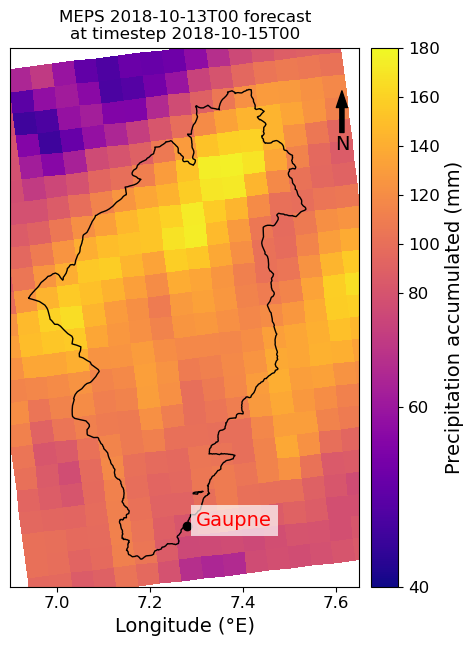

In [ ]:
import matplotlib.colors as mcolors

P = ds_sub.precipitation_amount_acc.isel(time=48, ensemble_member=0).squeeze("height0")


fig, ax = plt.subplots(figsize=(7.5,7))

norm = mcolors.TwoSlopeNorm(vmin=40, vcenter=70, vmax=180)

pcm = ax.pcolormesh(
    ds_sub.longitude,
    ds_sub.latitude,
    P,
    cmap="plasma",
    norm=norm,
    shading="nearest"
)


cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("Precipitation accumulated (mm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Catchment boundary
catchment_ll_gaupne.boundary.plot(ax=ax, color="black", linewidth=1)

gaupne_lat = 61.412
gaupne_lon = 7.28
ax.plot(gaupne_lon, gaupne_lat, 'ko', markersize=6)
ax.text(gaupne_lon+0.02, gaupne_lat, "Gaupne",
        color="red", fontsize=14,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax.annotate('N',
            xy=(0.95, 0.92), xytext=(0.95, 0.82),
            arrowprops=dict(facecolor='black', width=3, headwidth=8),
            ha='center', va='center',
            fontsize=14,
            xycoords=ax.transAxes)

ax.set_title(
    f"MEPS {np.datetime_as_string(ds_sub.time.values[0], unit='h')} forecast\n"
    f"at timestep {np.datetime_as_string(ds_sub.time.values[48], unit='h')}",
    fontsize=12
)
ax.set_xlim(6.9, 7.65)
ax.set_ylim(61.35, 61.9)

ax.set_yticks([])
ax.tick_params(labelsize=12)

ax.set_xlabel("Longitude (°E)", fontsize=14)
#ax.set_ylabel("Latitude (°N)")

plt.show()